<a href="https://colab.research.google.com/github/zshaan25/Image_Classification_CNN/blob/main/Image%20Classification_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Convolutional Neural Network (CNN) for Image Classification
**Datasets:** CIFAR-100 and Fashion-MNIST  
**Framework:** TensorFlow / Keras


## Step 0 — Install & Import Libraries

In [ ]:
# Install required libraries
# !pip install tensorflow scikit-learn seaborn matplotlib

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Task 1 — Load & Preprocess Data

### 1A — Fashion-MNIST

In [ ]:
# ── Fashion-MNIST ──────────────────────────────────────────
# 10 classes, 28x28 grayscale images

fashion_classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

# load dataset (auto-downloads if not present)
(fm_x_train, fm_y_train), (fm_x_test, fm_y_test) = keras.datasets.fashion_mnist.load_data()

# normalize pixel values from [0, 255] to [0, 1]
fm_x_train = fm_x_train / 255.0
fm_x_test  = fm_x_test  / 255.0

# add channel dimension: (28, 28) → (28, 28, 1)
fm_x_train = fm_x_train[..., np.newaxis]
fm_x_test  = fm_x_test[...,  np.newaxis]

# split training into 80% train / 20% validation
split = int(0.8 * len(fm_x_train))
fm_x_val,   fm_y_val   = fm_x_train[split:], fm_y_train[split:]
fm_x_train, fm_y_train = fm_x_train[:split], fm_y_train[:split]

print('Fashion-MNIST shapes:')
print(f'  Train : {fm_x_train.shape}  Labels: {fm_y_train.shape}')
print(f'  Val   : {fm_x_val.shape}    Labels: {fm_y_val.shape}')
print(f'  Test  : {fm_x_test.shape}   Labels: {fm_y_test.shape}')

Fashion-MNIST shapes:
  Train : (48000, 28, 28, 1)  Labels: (48000,)
  Val   : (12000, 28, 28, 1)    Labels: (12000,)
  Test  : (10000, 28, 28, 1)   Labels: (10000,)


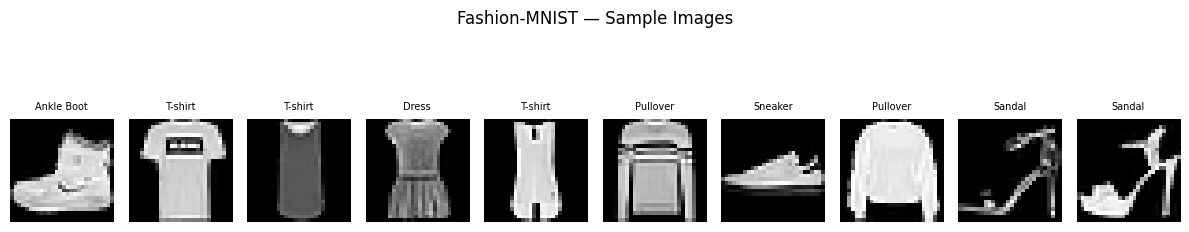

In [ ]:
# visualize some sample images
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(fm_x_train[i].squeeze(), cmap='gray')
    plt.title(fashion_classes[fm_y_train[i]], fontsize=7)
    plt.axis('off')
plt.suptitle('Fashion-MNIST — Sample Images', fontsize=12)
plt.tight_layout()
plt.savefig('fashion_samples.png', dpi=120)
plt.show()

### 1B — CIFAR-100

In [ ]:
# ── CIFAR-100 ──────────────────────────────────────────────
# 100 classes, 32x32 RGB images

(c_x_train, c_y_train), (c_x_test, c_y_test) = keras.datasets.cifar100.load_data()

# normalize
c_x_train = c_x_train / 255.0
c_x_test  = c_x_test  / 255.0

# squeeze label shape: (N, 1) → (N,)
c_y_train = c_y_train.flatten()
c_y_test  = c_y_test.flatten()

# 80/20 train/val split
split = int(0.8 * len(c_x_train))
c_x_val,   c_y_val   = c_x_train[split:], c_y_train[split:]
c_x_train, c_y_train = c_x_train[:split], c_y_train[:split]

print('CIFAR-100 shapes:')
print(f'  Train : {c_x_train.shape}  Labels: {c_y_train.shape}')
print(f'  Val   : {c_x_val.shape}    Labels: {c_y_val.shape}')
print(f'  Test  : {c_x_test.shape}   Labels: {c_y_test.shape}')

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
CIFAR-100 shapes:
  Train : (40000, 32, 32, 3)  Labels: (40000,)
  Val   : (10000, 32, 32, 3)    Labels: (10000,)
  Test  : (10000, 32, 32, 3)   Labels: (10000,)


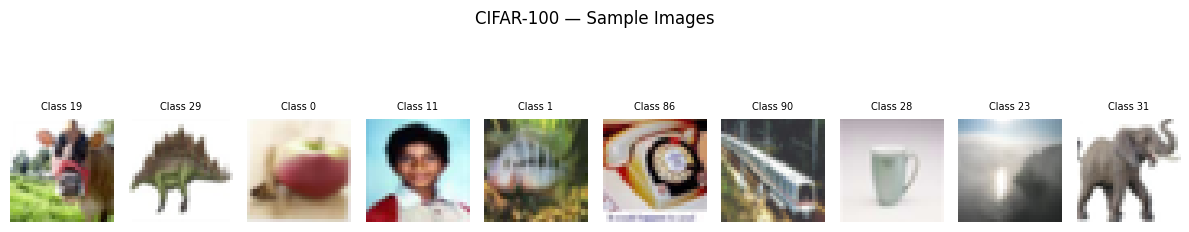

In [ ]:
# visualize some CIFAR-100 samples
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(c_x_train[i])
    plt.title(f'Class {c_y_train[i]}', fontsize=7)
    plt.axis('off')
plt.suptitle('CIFAR-100 — Sample Images', fontsize=12)
plt.tight_layout()
plt.savefig('cifar100_samples.png', dpi=120)
plt.show()

---
## Task 2 — Build CNN Models

### 2A — CNN Model for Fashion-MNIST

In [ ]:
def build_fashion_model():
    """
    Simple CNN for Fashion-MNIST:
    Input (28x28x1) → Conv → Conv → Pool → Conv → Pool → Dense → Output (10)
    """
    model = keras.Sequential([
        # ── Convolutional Block 1 ──
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),       # 28x28 → 14x14
        layers.Dropout(0.25),

        # ── Convolutional Block 2 ──
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),       # 14x14 → 7x7
        layers.Dropout(0.25),

        # ── Fully Connected Layers ──
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')  # 10 output classes
    ], name='CNN_FashionMNIST')

    return model

fm_model = build_fashion_model()
fm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_FashionMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,202 (1.79 MB)

 Trainable params: 468,010 (1.79 MB)

 Non-trainable params: 192 (768.00 B)

### 2B — CNN Model for CIFAR-100

In [ ]:
def build_cifar100_model():
    """
    Deeper CNN for CIFAR-100 (harder task — 100 classes):
    Input (32x32x3) → Block1 → Block2 → Block3 → Dense → Output (100)
    """
    model = keras.Sequential([
        # ── Block 1: 32 filters ──
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),       # 32x32 → 16x16
        layers.Dropout(0.2),

        # ── Block 2: 64 filters ──
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),       # 16x16 → 8x8
        layers.Dropout(0.3),

        # ── Block 3: 128 filters ──
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),       # 8x8 → 4x4
        layers.Dropout(0.4),

        # ── Fully Connected Layers ──
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(100, activation='softmax')  # 100 output classes
    ], name='CNN_CIFAR100')

    return model

c100_model = build_cifar100_model()
c100_model.summary()

Model: "CNN_CIFAR100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 838,148 (3.20 MB)

 Trainable params: 837,700 (3.20 MB)

 Non-trainable params: 448 (1.75 KB)

---
## Task 3 — Compile & Train Models

### 3A — Train Fashion-MNIST Model

In [ ]:
# compile with cross-entropy loss and Adam optimizer
fm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# callbacks: reduce LR when val_loss stops improving, stop early if no progress
callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                  restore_best_weights=True, verbose=1)
]

# train the model
fm_history = fm_model.fit(
    fm_x_train, fm_y_train,
    validation_data=(fm_x_val, fm_y_val),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete!')

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6970 - loss: 0.8171 - val_accuracy: 0.8599 - val_loss: 0.4130 - learning_rate: 0.0010
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7950 - loss: 0.5418 - val_accuracy: 0.8848 - val_loss: 0.3342 - learning_rate: 0.0010
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8411 - loss: 0.4345 - val_accuracy: 0.9004 - val_loss: 0.2790 - learning_rate: 0.0010
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8688 - loss: 0.3686 - val_accuracy: 0.8992 - val_loss: 0.2611 - learning_rate: 0.0010
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8842 - loss: 0.3256 - val_accuracy: 0.9072 - val_loss: 0.2601 - learning_rate: 0.0010
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8946 - loss: 0.3001 - val_accuracy: 0.9142 - val_loss: 0.2312 - learning_rate: 0.0010
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8975 - loss: 0.2814 

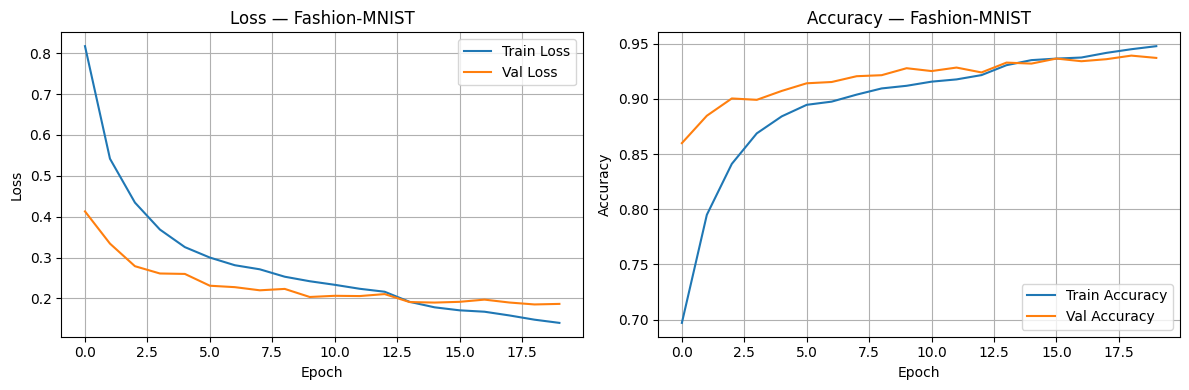

In [ ]:
# plot training and validation loss & accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(fm_history.history['loss'],     label='Train Loss')
ax1.plot(fm_history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss — Fashion-MNIST')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(fm_history.history['accuracy'],     label='Train Accuracy')
ax2.plot(fm_history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy — Fashion-MNIST')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('fashion_training_curves.png', dpi=120)
plt.show()

### 3B — Train CIFAR-100 Model

In [ ]:
c100_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_c = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                  restore_best_weights=True, verbose=1)
]

c100_history = c100_model.fit(
    c_x_train, c_y_train,
    validation_data=(c_x_val, c_y_val),
    epochs=20,
    batch_size=64,
    callbacks=callbacks_c,
    verbose=1
)

print('\nTraining complete!')

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.0121 - loss: 4.6001 - val_accuracy: 0.0146 - val_loss: 4.5504 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0141 - loss: 4.5470 - val_accuracy: 0.0164 - val_loss: 4.5039 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.0155 - loss: 4.5297 - val_accuracy: 0.0160 - val_loss: 4.4592 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0158 - loss: 4.5140 - val_accuracy: 0.0194 - val_loss: 4.4739 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0253 - loss: 4.4361 - val_accuracy: 0.0343 - val_loss: 4.3364 - learning_rate: 0.0010
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0433 - loss: 4.2847 - val_accuracy: 0.0757 - val_loss: 4.1095 - learning_rate: 0.0010
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0655 - loss: 4.0933

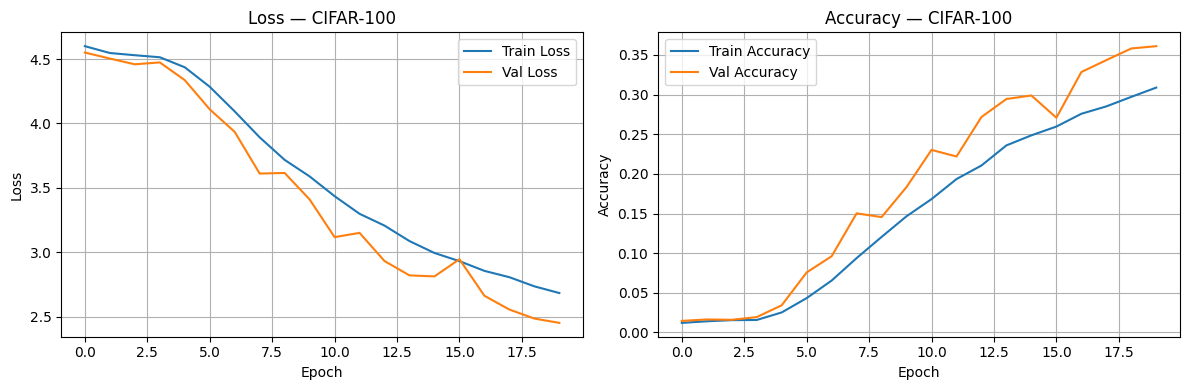

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(c100_history.history['loss'],     label='Train Loss')
ax1.plot(c100_history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss — CIFAR-100')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(c100_history.history['accuracy'],     label='Train Accuracy')
ax2.plot(c100_history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy — CIFAR-100')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('cifar100_training_curves.png', dpi=120)
plt.show()

---
## Task 4 — Evaluate Models

### 4A — Evaluate Fashion-MNIST

In [ ]:
# get predictions
fm_preds = np.argmax(fm_model.predict(fm_x_test), axis=1)

# test loss and accuracy
fm_loss, fm_acc = fm_model.evaluate(fm_x_test, fm_y_test, verbose=0)
print(f'Fashion-MNIST Test Accuracy: {fm_acc*100:.2f}%')
print(f'Fashion-MNIST Test Loss    : {fm_loss:.4f}')
print()

# precision, recall, f1-score
print('Classification Report:')
print(classification_report(fm_y_test, fm_preds, target_names=fashion_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Fashion-MNIST Test Accuracy: 93.43%
Fashion-MNIST Test Loss    : 0.2094

Classification Report:
              precision    recall  f1-score   support

     T-shirt       0.87      0.91      0.89      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.90      0.92      0.91      1000
       Dress       0.93      0.94      0.93      1000
        Coat       0.89      0.92      0.91      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.84      0.74      0.78      1000
     Sneaker       0.96      0.98      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle Boot       0.99      0.96      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



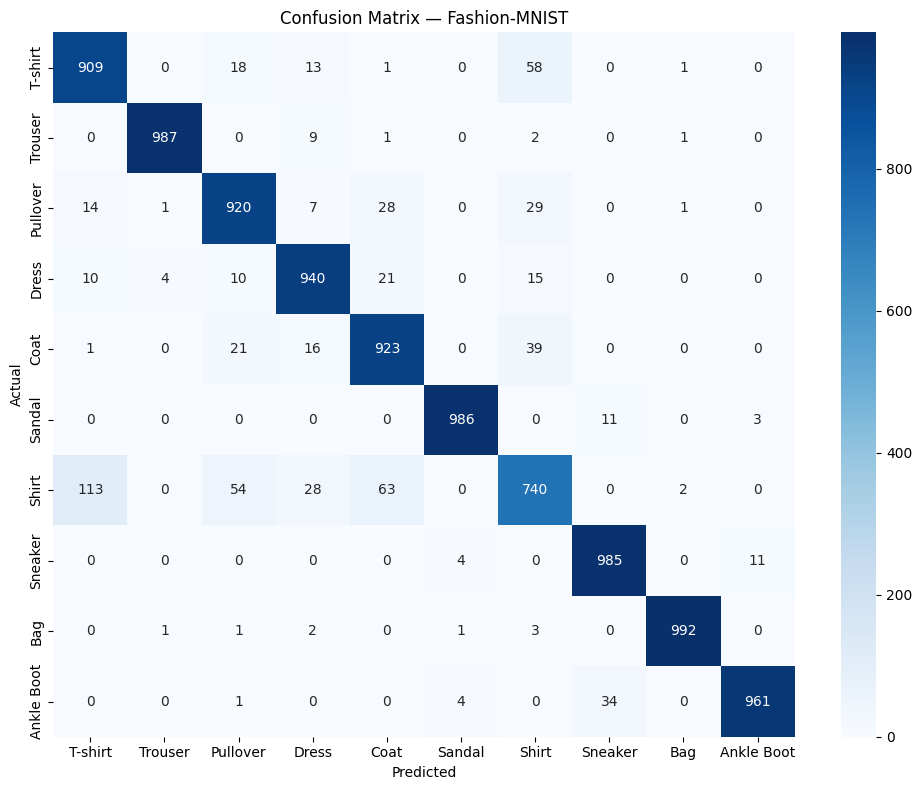

In [ ]:
# confusion matrix
cm = confusion_matrix(fm_y_test, fm_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=fashion_classes,
            yticklabels=fashion_classes)
plt.title('Confusion Matrix — Fashion-MNIST')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('fashion_confusion_matrix.png', dpi=120)
plt.show()

### 4B — Evaluate CIFAR-100

In [ ]:
c_preds = np.argmax(c100_model.predict(c_x_test), axis=1)

c_loss, c_acc = c100_model.evaluate(c_x_test, c_y_test, verbose=0)
print(f'CIFAR-100 Test Accuracy: {c_acc*100:.2f}%')
print(f'CIFAR-100 Test Loss    : {c_loss:.4f}')
print()

# weighted avg metrics (too many classes to show per-class)
print('Classification Report (weighted avg):')
print(classification_report(c_y_test, c_preds, digits=3))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
CIFAR-100 Test Accuracy: 37.29%
CIFAR-100 Test Loss    : 2.4169

Classification Report (weighted avg):
              precision    recall  f1-score   support

           0      0.579     0.660     0.617       100
           1      0.337     0.310     0.323       100
           2      0.182     0.140     0.158       100
           3      0.176     0.180     0.178       100
           4      0.151     0.110     0.127       100
           5      0.322     0.390     0.353       100
           6      0.372     0.320     0.344       100
           7      0.405     0.300     0.345       100
           8      0.750     0.480     0.585       100
           9      0.688     0.550     0.611       100
          10      0.345     0.290     0.315       100
          11      0.317     0.130     0.184       100
          12      0.456     0.470     0.463       100
          13      0.289     0.260     0.274       100
          14      0.231     0.150     0.182  

---
## Task 5 — Hyperparameter Tuning

In [ ]:
# Experiment with different learning rates, batch sizes, and dropout rates
# We test on Fashion-MNIST for speed (3 epochs each to compare)

experiments = [
    {'lr': 0.01,   'batch': 32,  'dropout': 0.3},
    {'lr': 0.01,   'batch': 64,  'dropout': 0.5},
    {'lr': 0.001,  'batch': 32,  'dropout': 0.3},
    {'lr': 0.001,  'batch': 64,  'dropout': 0.5},  # our default
    {'lr': 0.001,  'batch': 128, 'dropout': 0.3},
    {'lr': 0.0001, 'batch': 64,  'dropout': 0.5},
]

results = []

for cfg in experiments:
    print(f"\nTesting: LR={cfg['lr']} | Batch={cfg['batch']} | Dropout={cfg['dropout']}")

    # build a fresh model with this dropout
    m = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(cfg['dropout']),
        layers.Dense(10, activation='softmax')
    ])

    m.compile(optimizer=keras.optimizers.Adam(cfg['lr']),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

    hist = m.fit(fm_x_train, fm_y_train,
                 validation_data=(fm_x_val, fm_y_val),
                 epochs=3, batch_size=cfg['batch'], verbose=0)

    best_val_acc = max(hist.history['val_accuracy'])
    label = f"LR={cfg['lr']}\nBS={cfg['batch']}\nDO={cfg['dropout']}"
    results.append({'label': label, 'val_acc': best_val_acc * 100})
    print(f"  → Best Val Acc: {best_val_acc*100:.2f}%")

print('\nAll experiments done!')


Testing: LR=0.01 | Batch=32 | Dropout=0.3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  → Best Val Acc: 88.62%

Testing: LR=0.01 | Batch=64 | Dropout=0.5
  → Best Val Acc: 87.94%

Testing: LR=0.001 | Batch=32 | Dropout=0.3
  → Best Val Acc: 90.51%

Testing: LR=0.001 | Batch=64 | Dropout=0.5
  → Best Val Acc: 89.70%

Testing: LR=0.001 | Batch=128 | Dropout=0.3
  → Best Val Acc: 89.88%

Testing: LR=0.0001 | Batch=64 | Dropout=0.5
  → Best Val Acc: 84.96%

All experiments done!


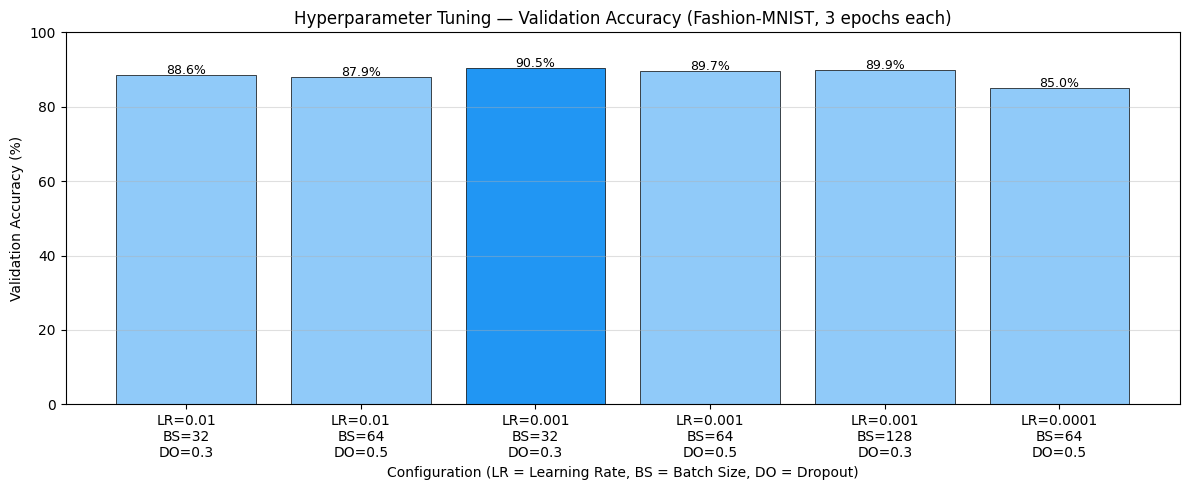

Best configuration: LR=0.001 | BS=32 | DO=0.3
Best Validation Accuracy: 90.51%


In [ ]:
# visualize hyperparameter results
labels   = [r['label']   for r in results]
val_accs = [r['val_acc'] for r in results]

colors = ['#2196F3' if v == max(val_accs) else '#90CAF9' for v in val_accs]

plt.figure(figsize=(12, 5))
bars = plt.bar(labels, val_accs, color=colors, edgecolor='black', linewidth=0.5)
for bar, acc in zip(bars, val_accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{acc:.1f}%', ha='center', fontsize=9)
plt.ylim(0, 100)
plt.title('Hyperparameter Tuning — Validation Accuracy (Fashion-MNIST, 3 epochs each)')
plt.ylabel('Validation Accuracy (%)')
plt.xlabel('Configuration (LR = Learning Rate, BS = Batch Size, DO = Dropout)')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('hyperparameter_results.png', dpi=120)
plt.show()

best = results[val_accs.index(max(val_accs))]
print(f"Best configuration: {best['label'].replace(chr(10), ' | ')}")
print(f"Best Validation Accuracy: {best['val_acc']:.2f}%")

---
## Summary of Results

In [ ]:
print('=' * 50)
print('         FINAL RESULTS SUMMARY')
print('=' * 50)
print(f'Fashion-MNIST  → Test Accuracy: {fm_acc*100:.2f}%')
print(f'CIFAR-100      → Test Accuracy: {c_acc*100:.2f}%')
print('=' * 50)
print('All plots saved:')
print('  fashion_samples.png')
print('  fashion_training_curves.png')
print('  fashion_confusion_matrix.png')
print('  cifar100_samples.png')
print('  cifar100_training_curves.png')
print('  hyperparameter_results.png')

         FINAL RESULTS SUMMARY
Fashion-MNIST  → Test Accuracy: 93.43%
CIFAR-100      → Test Accuracy: 37.29%
All plots saved:
  fashion_samples.png
  fashion_training_curves.png
  fashion_confusion_matrix.png
  cifar100_samples.png
  cifar100_training_curves.png
  hyperparameter_results.png
